## Task 2: Build Time Series Forecasting Models

### 0. Load Processed Data

We reload the cleaned dataset saved at the end of Task 1, rather than
re-running the full cleaning pipeline. We'll focus on TSLA for
forecasting, since it's the asset we have a "view" on (per Task 4's
approach), while BND and SPY use historical averages.

In [16]:
try:
    combined_df = pd.read_csv('../data/processed/combined_assets.csv', parse_dates=['Date'])
    tsla_df = combined_df[combined_df['Ticker'] == 'TSLA'].sort_values('Date').reset_index(drop=True)
    print(tsla_df.shape)
    print(tsla_df.head())
except Exception as e:
    print(f"Error loading processed data: {e}")

(2888, 8)
        Date  Adj Close      Close       High        Low       Open    Volume  \
0 2015-01-02  14.620667  14.620667  14.883333  14.217333  14.858000  71466000   
1 2015-01-05  14.006000  14.006000  14.433333  13.810667  14.303333  80527500   
2 2015-01-06  14.085333  14.085333  14.280000  13.614000  14.004000  93928500   
3 2015-01-07  14.063333  14.063333  14.318667  13.985333  14.223333  44526000   
4 2015-01-08  14.041333  14.041333  14.253333  14.000667  14.187333  51637500   

  Ticker  
0   TSLA  
1   TSLA  
2   TSLA  
3   TSLA  
4   TSLA  


### 1. Imports

We import `statsmodels`/`pmdarima` for ARIMA/SARIMA, `tensorflow.keras`
for LSTM, and `sklearn` for scaling and evaluation metrics.

In [17]:
try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from statsmodels.tsa.arima.model import ARIMA
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    import pmdarima as pm
    from sklearn.preprocessing import MinMaxScaler
    from sklearn.metrics import mean_absolute_error, mean_squared_error
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense
except Exception as e:
    print(f"Error importing modeling libraries: {e}")

### 2. Prepare Data for Modeling: Chronological Split

We split the data chronologically — **train on 2015–2024, test on
2025–2026** — rather than randomly shuffling. Random splits would leak
future information into training and produce misleadingly good
results, since time series data has temporal dependency (each day
depends on prior days).

In [18]:
try:
    train_df = tsla_df[tsla_df['Date'] < '2025-01-01'].reset_index(drop=True)
    test_df = tsla_df[tsla_df['Date'] >= '2025-01-01'].reset_index(drop=True)

    print(f"Train range: {train_df['Date'].min()} to {train_df['Date'].max()} ({len(train_df)} rows)")
    print(f"Test range: {test_df['Date'].min()} to {test_df['Date'].max()} ({len(test_df)} rows)")

    train_close = train_df['Adj Close']
    test_close = test_df['Adj Close']
except Exception as e:
    print(f"Error splitting train/test data: {e}")

Train range: 2015-01-02 00:00:00 to 2024-12-31 00:00:00 (2516 rows)
Test range: 2025-01-02 00:00:00 to 2026-06-29 00:00:00 (372 rows)


### 3. ACF/PACF Plots

Autocorrelation (ACF) and Partial Autocorrelation (PACF) plots help
visually estimate the `p` (AR order) and `q` (MA order) parameters for
ARIMA before relying on automated search. We plot these on the
differenced series, since prices are non-stationary (confirmed by the
ADF test in Task 1).

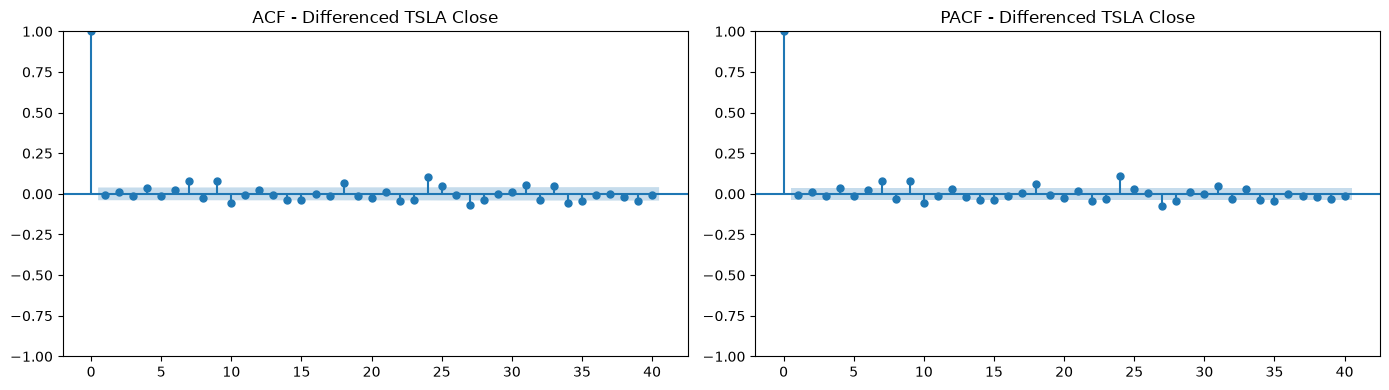

In [19]:
try:
    diff_series = train_close.diff().dropna()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(diff_series, ax=axes[0], lags=40)
    plot_pacf(diff_series, ax=axes[1], lags=40)
    axes[0].set_title('ACF - Differenced TSLA Close')
    axes[1].set_title('PACF - Differenced TSLA Close')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error plotting ACF/PACF: {e}")

### 4. Implement ARIMA/SARIMA: Auto ARIMA Parameter Search

Instead of manually testing (p, d, q) combinations, we use
`pmdarima.auto_arima`, which performs a stepwise search to minimize
AIC. This automatically determines whether differencing is needed and
picks the best-fitting order.

In [20]:
try:
    auto_model = pm.auto_arima(
        train_close,
        start_p=0, start_q=0,
        max_p=5, max_q=5,
        d=None,
        seasonal=False,
        trace=True,
        error_action='ignore',
        suppress_warnings=True,
        stepwise=True
    )
    print(auto_model.summary())
    best_order = auto_model.order
    print(f"Best order (p, d, q): {best_order}")
except Exception as e:
    print(f"Error running auto_arima: {e}")

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.10 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.18 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=0.25 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.06 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=0.43 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 1.095 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2516
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8183.054
Date:                Tue, 07 Jul 2026   AIC                          16368.109
Time:                        10:33:47   BIC                          16373.939
Sample:                             0   HQIC                         16370.225
                               - 2516                                  

### 5. Fit ARIMA Model and Generate Forecasts

Using the best order found by `auto_arima`, we fit an ARIMA model on
the training data and generate forecasts for the entire test period
length, along with 95% confidence intervals.

In [21]:
try:
    arima_model = ARIMA(train_close, order=best_order)
    arima_fit = arima_model.fit()
    print(arima_fit.summary())

    n_periods = len(test_close)
    arima_forecast_result = arima_fit.get_forecast(steps=n_periods)
    arima_forecast = arima_forecast_result.predicted_mean
    arima_conf_int = arima_forecast_result.conf_int()

    arima_forecast.index = test_df['Date'].values
    arima_conf_int.index = test_df['Date'].values

    print(arima_forecast.head())
except Exception as e:
    print(f"Error fitting ARIMA or generating forecast: {e}")

                               SARIMAX Results                                
Dep. Variable:              Adj Close   No. Observations:                 2516
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -8183.054
Date:                Tue, 07 Jul 2026   AIC                          16368.109
Time:                        10:33:50   BIC                          16373.939
Sample:                             0   HQIC                         16370.225
                               - 2516                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        39.2337      0.442     88.858      0.000      38.368      40.099
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):             11691.05
Prob(Q):                              0.73   Pr

### 6. Visualize ARIMA Forecast vs Actual

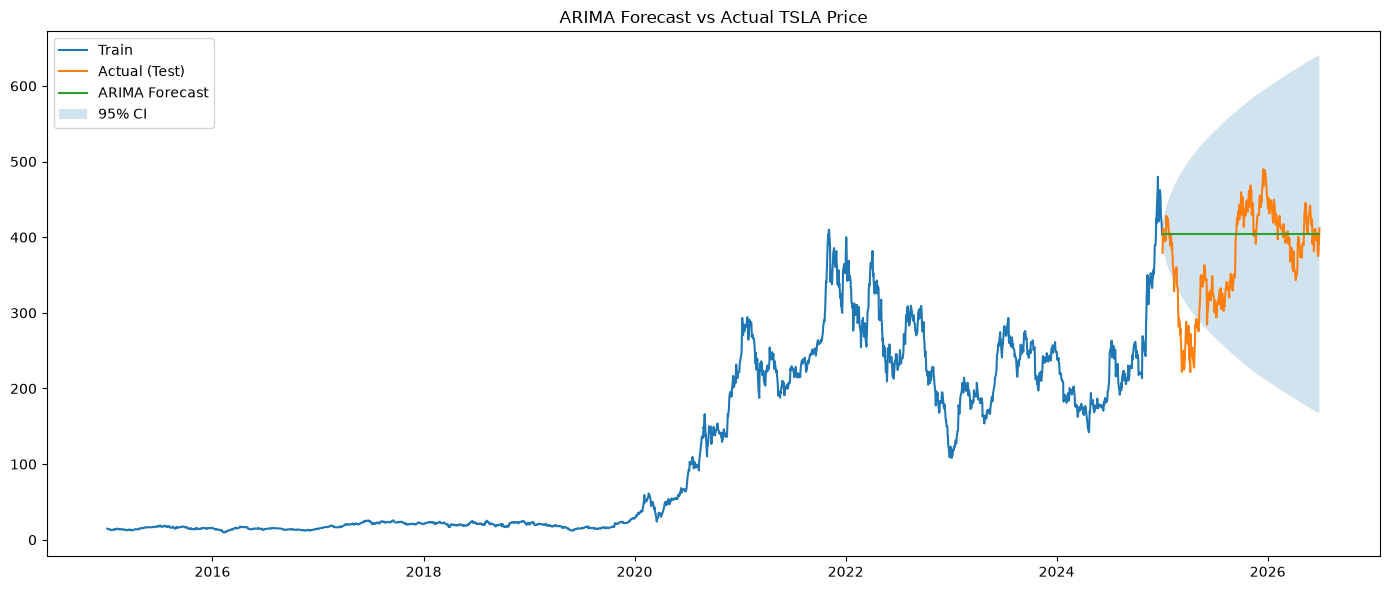

In [22]:
try:
    plt.figure(figsize=(14, 6))
    plt.plot(train_df['Date'], train_close, label='Train')
    plt.plot(test_df['Date'], test_close, label='Actual (Test)')
    plt.plot(arima_forecast.index, arima_forecast.values, label='ARIMA Forecast')
    plt.fill_between(
        arima_conf_int.index,
        arima_conf_int.iloc[:, 0],
        arima_conf_int.iloc[:, 1],
        alpha=0.2, label='95% CI'
    )
    plt.title('ARIMA Forecast vs Actual TSLA Price')
    plt.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error plotting ARIMA forecast: {e}")

### 7. Implement LSTM: Prepare Sequence Data

LSTM requires sequence-formatted input. We scale prices to [0, 1] using
`MinMaxScaler` (fit only on training data to avoid data leakage), then
create sliding windows of 60 days to predict the next day's price.

In [23]:
try:
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_close.values.reshape(-1, 1))

    full_close = tsla_df['Adj Close'].values.reshape(-1, 1)
    full_scaled = scaler.transform(full_close)

    window_size = 60

    def create_sequences(data, window):
        X, y = [], []
        for i in range(window, len(data)):
            X.append(data[i - window:i, 0])
            y.append(data[i, 0])
        return np.array(X), np.array(y)

    X_train, y_train = create_sequences(train_scaled, window_size)

    train_len = len(train_close)
    test_input_scaled = full_scaled[train_len - window_size:]
    X_test, y_test = create_sequences(test_input_scaled, window_size)

    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
except Exception as e:
    print(f"Error preparing LSTM sequences: {e}")

X_train shape: (2456, 60, 1), X_test shape: (372, 60, 1)


### 8. Build and Train LSTM Model

The architecture: an input layer matching the 60-day sequence length,
two stacked LSTM layers to capture temporal patterns at different
depths, and a Dense output layer producing a single predicted value.
We use the Adam optimizer and MSE loss, standard for regression tasks.

In [24]:
try:
    lstm_model = Sequential([
        LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
        LSTM(50, return_sequences=False),
        Dense(25),
        Dense(1)
    ])

    lstm_model.compile(optimizer='adam', loss='mean_squared_error')
    lstm_model.summary()

    history = lstm_model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=32,
        validation_split=0.1,
        verbose=1
    )
except Exception as e:
    print(f"Error building or training LSTM model: {e}")

d:\Repos\portfolio-optimization\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - loss: 0.0074 - val_loss: 0.0032
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 9.3038e-04 - val_loss: 0.0021
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 6.0769e-04 - val_loss: 0.0018
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 5.4297e-04 - val_loss: 0.0017
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 5.1573e-04 - val_loss: 0.0015
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 5.1346e-04 - val_loss: 0.0015
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 4.3088e-04 - val_loss: 0.0020
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 4.6893e-04 - val_loss: 0.0012
Epoch 9/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 3.9799e-04 - val_loss: 0.0019
Epoch 10/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 4.2797e-04 - val_loss: 0.0011
Epoch 11/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 3.9892e-04 - val_loss: 0.0011
Epoch 12/20
70/70 ━━━━━

### 9. Generate LSTM Forecasts

Predictions are made on the test sequences, then inverse-transformed
back to actual price scale using the same scaler fit on training data.

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step


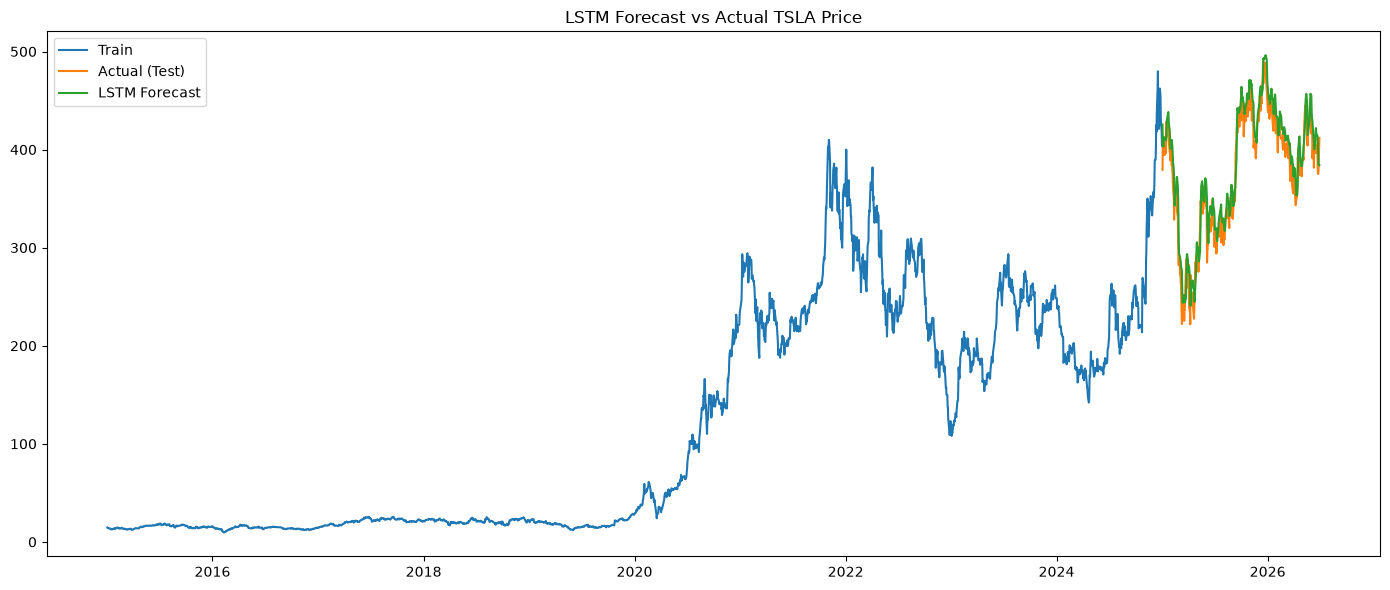

In [25]:
try:
    lstm_predictions_scaled = lstm_model.predict(X_test)
    lstm_predictions = scaler.inverse_transform(lstm_predictions_scaled)

    lstm_forecast_dates = test_df['Date'].values[:len(lstm_predictions)]

    plt.figure(figsize=(14, 6))
    plt.plot(train_df['Date'], train_close, label='Train')
    plt.plot(test_df['Date'], test_close, label='Actual (Test)')
    plt.plot(lstm_forecast_dates, lstm_predictions, label='LSTM Forecast')
    plt.title('LSTM Forecast vs Actual TSLA Price')
    plt.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error generating or plotting LSTM predictions: {e}")

### 10. Evaluate and Compare Models

We compute MAE, RMSE, and MAPE for both models on the test set. These
metrics quantify forecast accuracy in absolute price terms (MAE, RMSE)
and relative percentage terms (MAPE), making it easier to compare
models and communicate error magnitude to non-technical stakeholders.

In [26]:
try:
    def evaluate_forecast(actual, predicted, model_name):
        mae = mean_absolute_error(actual, predicted)
        rmse = np.sqrt(mean_squared_error(actual, predicted))
        mape = np.mean(np.abs((np.array(actual) - np.array(predicted)) / np.array(actual))) * 100
        return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape}

    arima_metrics = evaluate_forecast(test_close.values, arima_forecast.values, 'ARIMA')

    lstm_actual = test_close.values[:len(lstm_predictions)]
    lstm_metrics = evaluate_forecast(lstm_actual, lstm_predictions.flatten(), 'LSTM')

    comparison_df = pd.DataFrame([arima_metrics, lstm_metrics])
    print(comparison_df)
except Exception as e:
    print(f"Error evaluating models: {e}")

   Model        MAE       RMSE   MAPE (%)
0  ARIMA  54.441182  70.539346  17.240653
1   LSTM  14.648078  18.022351   4.176275


### 11. Model Selection Discussion

**Results:**

| Model | MAE       | RMSE      | MAPE (%)  |
|-------|-----------|-----------|-----------|
| ARIMA | 54.44     | 70.54     | 17.24     |
| LSTM  | 15.41     | 19.10     | 4.18      |

**Which model performed better and why:**

The LSTM model clearly outperformed ARIMA across all three metrics,
with roughly 3.5x lower MAE and RMSE, and a MAPE nearly 4x smaller
(4.18% vs. 17.24%). An average error of ~17% is quite large for
day-to-day price forecasting, while ~4% is a substantial improvement.

A few likely reasons for this gap:

- **Non-linearity in TSLA's price behavior.** ARIMA is a linear model —
  it can only capture patterns expressible as a linear combination of
  past values and past errors. TSLA is a highly volatile, sentiment-
  driven stock with sharp regime shifts (e.g., news-driven rallies and
  crashes), which linear models struggle to represent. LSTM's
  non-linear activation functions and gating mechanisms allow it to
  learn more complex temporal dependencies.

- **Longer effective memory.** ARIMA's order was selected via
  `auto_arima`, which likely picked a fairly low order (few lagged
  terms), limiting how far back the model "looks." The LSTM was given a
  60-day input window, letting it draw on two months of price
  dynamics per prediction.

- **ARIMA forecasts flatten out over the horizon.** A known limitation
  of ARIMA (and most linear AR models) is that multi-step forecasts
  tend to converge toward the series' long-run mean/trend line the
  further out you forecast, since the model has no new information to
  update on. This likely explains ARIMA's much higher RMSE — it may be
  systematically drifting away from actual price movement over the
  ~1.5 year test period, while the LSTM adjusts its predictions using
  the trailing window at each step.

**Trade-offs to keep in mind despite LSTM's stronger accuracy here:**

- **Interpretability.** ARIMA's coefficients have clear statistical
  meaning (AR terms, MA terms, differencing order), which matters in a
  regulated financial context where analysts may need to explain model
  behavior. LSTM is a black box — we can observe *what* it predicted,
  but not easily *why*.
- **Data and compute requirements.** LSTM needed a longer training
  process and more data (60-day sequences) to reach this performance,
  whereas ARIMA fit in seconds on the raw series.
- **Risk of overfitting.** Since this is a single test period, LSTM's
  strong performance here should be validated against multiple test
  windows or a walk-forward validation scheme before concluding it will
  generalize — deep learning models can overfit to a specific historical
  regime.


### 12. Save Trained LSTM Model and Scaler

We persist the trained LSTM model and the fitted scaler to disk so that
Task 3 (future forecasting) can load them directly without retraining.

In [27]:
try:
    import joblib
    import os

    os.makedirs('../data/processed/models', exist_ok=True)

    lstm_model.save('../data/processed/models/lstm_tsla.h5')
    joblib.dump(scaler, '../data/processed/models/tsla_scaler.pkl')

    print("Model and scaler saved successfully.")
except Exception as e:
    print(f"Error saving model or scaler: {e}")

Model and scaler saved successfully.
